# Yuva Virtual Data Science with Python Trainee
## Week 1: Data Acquisition, Cleaning, and Preprocessing

### Project: Titanic Dataset Analysis

**Objective:**  
To acquire, inspect, clean, preprocess, and perform preliminary analysis
on the Titanic passenger dataset using Python.

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [54]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [55]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [56]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 15


In [57]:
print("Dataset shape:", df.shape)
print("Columns in the dataset:")
print(df.columns.tolist())
df.info()

Dataset shape: (891, 15)
Columns in the dataset:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone  

In [58]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [59]:
# Calculate missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage.round(2))

Missing value percentage:
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


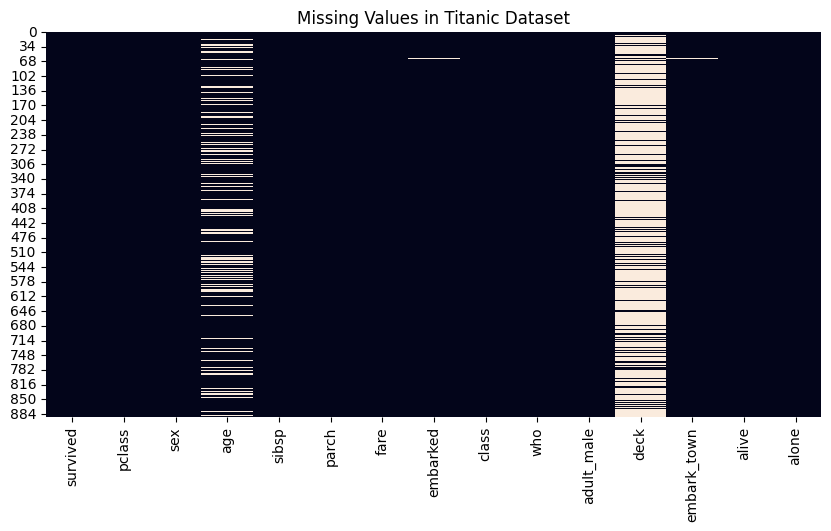

In [60]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Titanic Dataset")
plt.show()

In [61]:
print("Age missing values:", df["age"].isnull().sum())
print("Embarked missing values:", df["embarked"].isnull().sum())
print("Deck missing values:", df["deck"].isnull().sum())

Age missing values: 177
Embarked missing values: 2
Deck missing values: 688


In [62]:
df["age"] = df["age"].fillna(df["age"].median())
print("Missing Age values after cleaning:", df["age"].isnull().sum())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
print("Missing Embarked values after cleaning:", df["embarked"].isnull().sum())
df = df.drop(columns=["deck"])

Missing Age values after cleaning: 0
Missing Embarked values after cleaning: 0


In [63]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [64]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 116


In [65]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Dataset shape after removing duplicates: (775, 14)
Duplicate rows remaining: 0


In [66]:
# Check data types of all columns
print("Data types of dataset columns:")
print(df.dtypes)
# Display numerical and categorical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Data types of dataset columns:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object
Numerical columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical columns:
['sex', 'embarked', 'who', 'embark_town', 'alive']


In [67]:
# Check unique values in categorical columns
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


sex:
['male' 'female']

embarked:
['S' 'C' 'Q']

who:
['man' 'woman' 'child']

embark_town:
['Southampton' 'Cherbourg' 'Queenstown' nan]

alive:
['no' 'yes']


In [68]:
print("Sex values:")
print(df["sex"].value_counts())

print("\nEmbarked values:")
print(df["embarked"].value_counts())

print("\nClass values:")
print(df["class"].value_counts())

print("\nWho values:")
print(df["who"].value_counts())

Sex values:
sex
male      483
female    292
Name: count, dtype: int64

Embarked values:
embarked
S    562
C    155
Q     58
Name: count, dtype: int64

Class values:
class
Third     401
First     210
Second    164
Name: count, dtype: int64

Who values:
who
man      443
woman    250
child     82
Name: count, dtype: int64


In [69]:
# Standardize categorical text values
for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.lower()

print("Categorical values standardized successfully.")
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Categorical values standardized successfully.

sex:
['male' 'female']

embarked:
['s' 'c' 'q']

who:
['man' 'woman' 'child']

embark_town:
['southampton' 'cherbourg' 'queenstown' 'nan']

alive:
['no' 'yes']


In [70]:
# Statistical summary of numerical variables
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [71]:
# Complete statistical summary
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
count,775.000000,775.000000,775,775.000000,775.000000,775.000000,775.000000,775,775,775,775,775,775,775
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,4,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,s,Third,man,True,southampton,no,True
freq,NaN,NaN,483,NaN,NaN,NaN,NaN,562,401,443,443,560,455,437
mean,0.412903,2.246452,NaN,29.581187,0.529032,0.420645,34.878403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.492674,0.853574,NaN,13.766359,0.990326,0.840565,52.408474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,1.000000,NaN,21.000000,0.000000,0.000000,8.050000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,15.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,36.000000,1.000000,1.000000,34.197900,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
numerical_columns = ["age", "fare", "sibsp", "parch"]

In [73]:
# Detect outliers using the IQR method

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"\n{column}")
    print("Q1:", round(Q1, 2))
    print("Q3:", round(Q3, 2))
    print("Lower Bound:", round(lower_bound, 2))
    print("Upper Bound:", round(upper_bound, 2))
    print("Number of outliers:", len(outliers))


age
Q1: 21.0
Q3: 36.0
Lower Bound: -1.5
Upper Bound: 58.5
Number of outliers: 27

fare
Q1: 8.05
Q3: 34.2
Lower Bound: -31.17
Upper Bound: 73.42
Number of outliers: 102

sibsp
Q1: 0.0
Q3: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
Number of outliers: 39

parch
Q1: 0.0
Q3: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
Number of outliers: 15


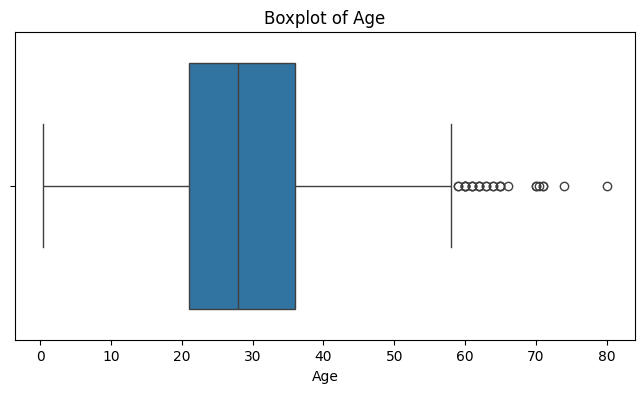

In [74]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["age"])

plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()

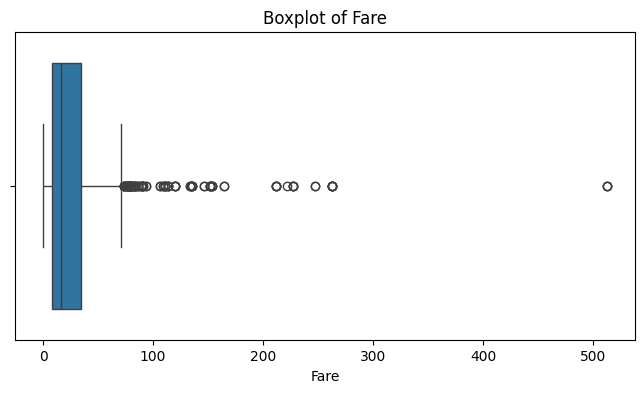

In [75]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["fare"])

plt.title("Boxplot of Fare")
plt.xlabel("Fare")
plt.show()

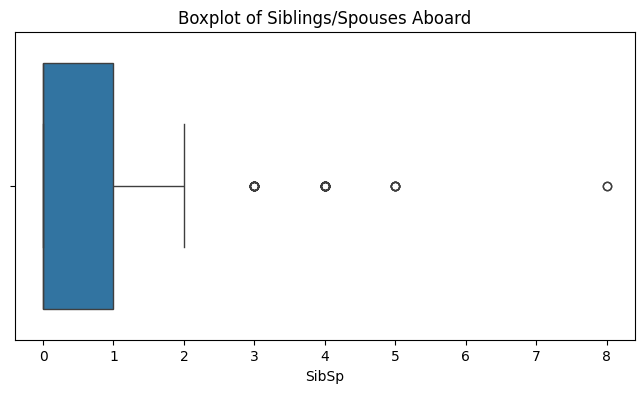

In [76]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["sibsp"])

plt.title("Boxplot of Siblings/Spouses Aboard")
plt.xlabel("SibSp")
plt.show()

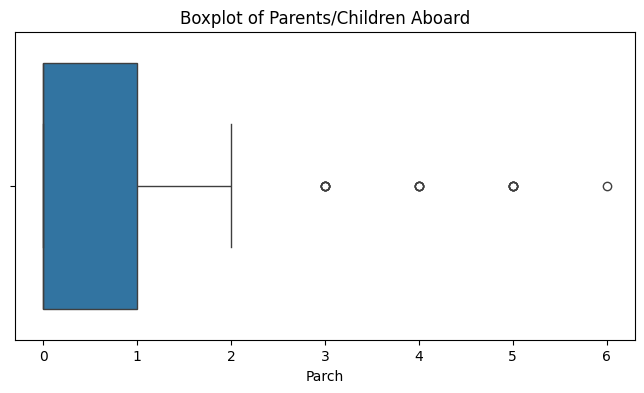

In [77]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["parch"])

plt.title("Boxplot of Parents/Children Aboard")
plt.xlabel("Parch")
plt.show()

In [78]:
# Handle extreme values using IQR capping

for column in ["age", "fare"]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

print("Outlier treatment completed using IQR capping.")

Outlier treatment completed using IQR capping.


In [79]:
print(df[["age", "fare"]].describe())

              age        fare
count  775.000000  775.000000
mean    29.363123   26.593137
std     13.211598   22.873099
min      0.420000    0.000000
25%     21.000000    8.050000
50%     28.000000   15.900000
75%     36.000000   34.197900
max     58.500000   73.419750


In [80]:
print("========== FINAL DATA QUALITY CHECK ==========")

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

========== FINAL DATA QUALITY CHECK ==========

Dataset shape:
(775, 14)

Missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Duplicate rows:
10

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object


In [81]:
# Create a copy for preprocessing
processed_df = df.copy()

print("Created processed dataset.")
print(processed_df.shape)
# One-hot encode categorical variables

processed_df = pd.get_dummies(
    processed_df,
    columns=["sex", "embarked", "class", "who"],
    drop_first=True,
    dtype=int
)

print("Categorical encoding completed.")
print("Processed dataset shape:", processed_df.shape)
processed_df.head()

Created processed dataset.
(775, 14)
Categorical encoding completed.
Processed dataset shape: (775, 17)


,survived,pclass,age,sibsp,parch,fare,adult_male,embark_town,alive,alone,sex_male,embarked_q,embarked_s,class_Second,class_Third,who_man,who_woman
0,0,3,22.0,1,0,7.2500,True,southampton,no,False,1,0,1,0,1,1,0
1,1,1,38.0,1,0,71.2833,False,cherbourg,yes,False,0,0,0,0,0,0,1
2,1,3,26.0,0,0,7.9250,False,southampton,yes,True,0,0,1,0,1,0,1
3,1,1,35.0,1,0,53.1000,False,southampton,yes,False,0,0,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,True,southampton,no,True,1,0,1,0,1,1,0


In [82]:
from sklearn.preprocessing import StandardScaler

# Columns to scale
scale_columns = ["age", "fare", "sibsp", "parch"]

scaler = StandardScaler()

processed_df[scale_columns] = scaler.fit_transform(
    processed_df[scale_columns]
)

print("Feature scaling completed.")

processed_df[scale_columns].head()

processed_df[scale_columns].describe()

Feature scaling completed.


,age,fare,sibsp,parch
count,7.750000e+02,7.750000e+02,7.750000e+02,7.750000e+02
mean,3.025537e-16,-3.896525e-17,-3.208903e-17,1.375244e-17
std,1.000646e+00,1.000646e+00,1.000646e+00,1.000646e+00
min,-2.192151e+00,-1.163389e+00,-5.345452e-01,-5.007545e-01
25%,-6.334225e-01,-8.112198e-01,-5.345452e-01,-5.007545e-01
50%,-1.032428e-01,-4.678003e-01,-5.345452e-01,-5.007545e-01
75%,5.026768e-01,3.326910e-01,4.758756e-01,6.896894e-01
max,2.206826e+00,2.048557e+00,7.548821e+00,6.641909e+00


In [83]:
print("========== FINAL PREPROCESSED DATASET ==========")

print("Shape:", processed_df.shape)

print("\nMissing values:")
print(processed_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(processed_df.duplicated().sum())

print("\nColumns:")
print(processed_df.columns.tolist())

processed_df.head()

========== FINAL PREPROCESSED DATASET ==========
Shape: (775, 17)

Missing values:
0

Duplicate rows:
10

Columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'embark_town', 'alive', 'alone', 'sex_male', 'embarked_q', 'embarked_s', 'class_Second', 'class_Third', 'who_man', 'who_woman']


,survived,pclass,age,sibsp,parch,fare,adult_male,embark_town,alive,alone,sex_male,embarked_q,embarked_s,class_Second,class_Third,who_man,who_woman
0,0,3,-0.557683,0.475876,-0.500754,-0.846218,True,southampton,no,False,1,0,1,0,1,1,0
1,1,1,0.654157,0.475876,-0.500754,1.955092,False,cherbourg,yes,False,0,0,0,0,0,0,1
2,1,3,-0.254723,-0.534545,-0.500754,-0.816688,False,southampton,yes,True,0,0,1,0,1,0,1
3,1,1,0.426937,0.475876,-0.500754,1.159615,False,southampton,yes,False,0,0,1,0,0,0,1
4,0,3,0.426937,-0.534545,-0.500754,-0.811220,True,southampton,no,True,1,0,1,0,1,1,0


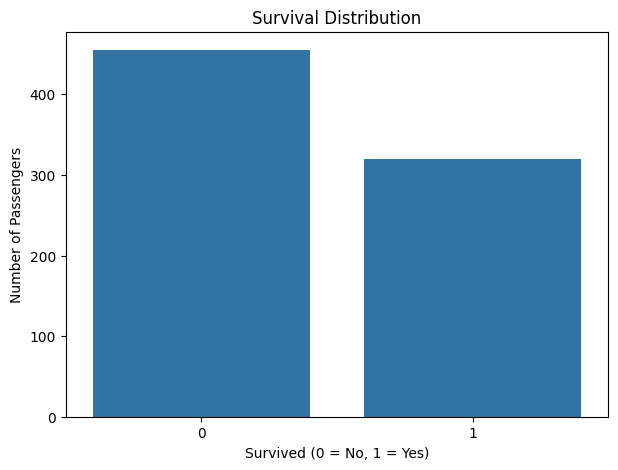

In [84]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="survived")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

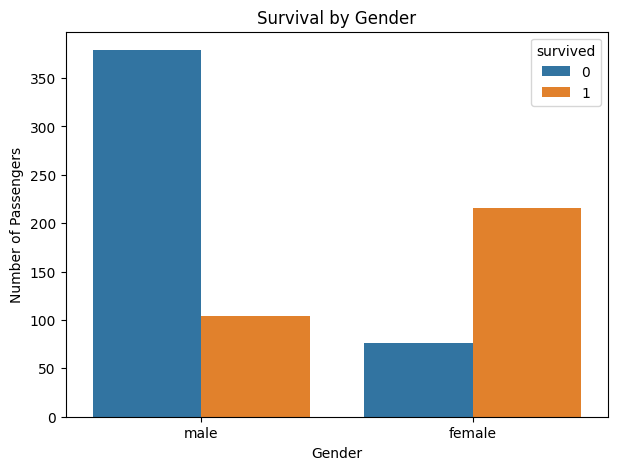

In [85]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

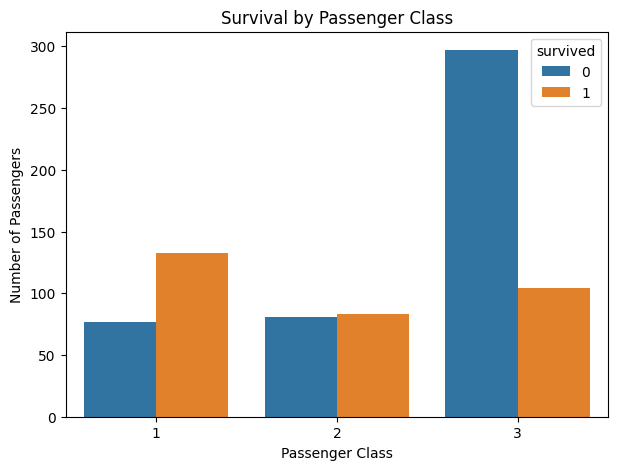

In [86]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="pclass", hue="survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

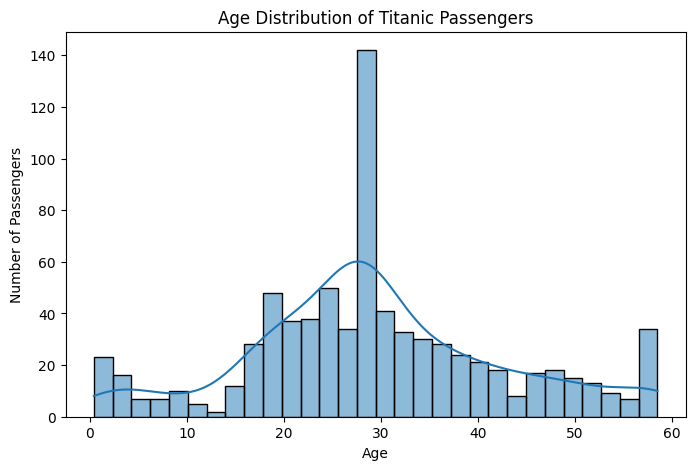

In [87]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

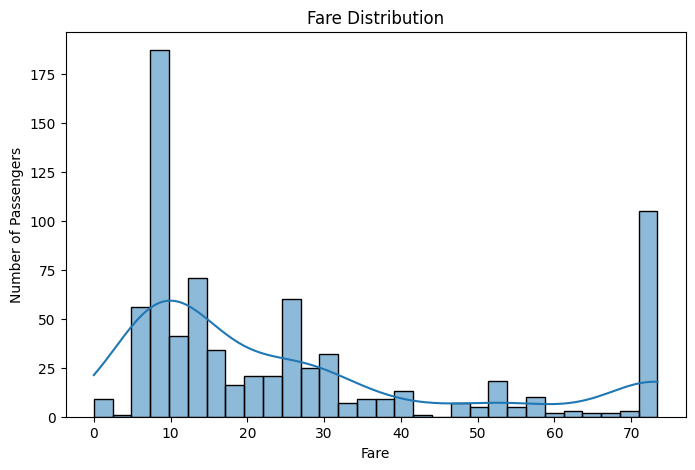

In [88]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [89]:
print("========== PRELIMINARY ANALYSIS ==========")

print("\nOverall survival rate:")
print(round(df["survived"].mean() * 100, 2), "%")

print("\nSurvival rate by gender:")
print((df.groupby("sex")["survived"].mean() * 100).round(2))

print("\nSurvival rate by passenger class:")
print((df.groupby("pclass")["survived"].mean() * 100).round(2))

print("\nAverage age:")
print(round(df["age"].mean(), 2))

print("\nMedian age:")
print(round(df["age"].median(), 2))

print("\nAverage fare:")
print(round(df["fare"].mean(), 2))

========== PRELIMINARY ANALYSIS ==========

Overall survival rate:
41.29 %

Survival rate by gender:
sex
female    73.97
male      21.53
Name: survived, dtype: float64

Survival rate by passenger class:
pclass
1    63.33
2    50.61
3    25.94
Name: survived, dtype: float64

Average age:
29.36

Median age:
28.0

Average fare:
26.59


In [90]:
# Save cleaned dataset
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved as titanic_cleaned.csv")

Cleaned dataset saved as titanic_cleaned.csv


In [91]:
# Save preprocessed dataset
processed_df.to_csv("titanic_preprocessed.csv", index=False)

print("Preprocessed dataset saved as titanic_preprocessed.csv")

Preprocessed dataset saved as titanic_preprocessed.csv


# Week 1 Conclusion

The Titanic dataset was successfully acquired and analyzed using Python.
The dataset was inspected for its structure, data types, missing values,
duplicate records, categorical inconsistencies, and potential outliers.

Missing numerical values in the Age column were handled using median
imputation, while missing categorical values in the Embarked column were
handled using mode imputation. The Deck column was removed because it
contained a substantial amount of missing information. Duplicate records
were checked and removed where necessary.

Outliers in continuous variables were identified using the Interquartile
Range (IQR) method. Extreme values in Age and Fare were handled using IQR
capping while preserving the observations.

Categorical variables were converted into numerical representations using
one-hot encoding, and selected numerical variables were standardized using
StandardScaler. The resulting dataset is suitable for further data
analysis and machine learning tasks.

Preliminary analysis was also performed to understand passenger survival,
gender, passenger class, age distribution, and fare distribution.

In [92]:
from google.colab import files

files.download("titanic_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
files.download("titanic_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>